In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/ML/'

Mounted at /content/drive


Data loading and split

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv(data_dir + 'rt_ciatox_2025_smiles.csv')

In [ ]:
#df = pd.read_csv(data_dir + 'RT_Ciatox_SMILES_2025.tsv', sep="\t")
#hs = df.loc[[312,313]] # holdout samples (hs)
#df = df.drop([312, 313], axis=0)

In [ ]:
smiles_column = df['SMILES']
target = df['RT']

smiles_train, smiles_holdout, y_train, y_holdout = train_test_split(smiles_column, target, train_size=0.70, random_state=42)

Descriptor calculation and selection

In [ ]:
!pip install mordredcommunity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 21.0 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from mordred import Calculator, descriptors
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV
from mlxtend.feature_selection import SequentialFeatureSelector

In [ ]:
mordred_calc = Calculator(descriptors.all, ignore_3D=True)

In [ ]:
train_mols = smiles_train.apply(Chem.MolFromSmiles)
mordred_train = mordred_calc.pandas(train_mols).dropna(axis=1, how='any')
mordred_train = mordred_train.select_dtypes(include=['float64', 'int64', 'float'])
mordred_train.head()

100%|██████████| 219/219 [00:40<00:00,  5.38it/s]


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
124,15.503979,13.870736,0,1,26.461156,2.416668,4.777054,26.461156,1.323058,3.934836,...,9.827416,68.921419,275.152144,6.711028,802,28,104.0,123.0,5.666667,4.527778
18,8.623181,8.305042,0,1,15.289155,2.263821,4.527642,15.289155,1.274096,3.368800,...,8.990317,41.960702,165.115364,6.115384,202,15,54.0,60.0,4.833333,2.888889
309,19.596789,14.889644,0,0,33.669015,2.478131,4.866960,33.669015,1.346761,4.162380,...,10.150621,74.146570,327.198700,6.543974,1525,39,132.0,157.0,6.027778,5.638889
104,12.037754,11.142483,0,1,18.238315,2.320010,4.640019,18.238315,1.139895,3.663695,...,9.470626,47.991812,239.107692,7.032579,454,20,78.0,85.0,7.756944,3.430556
19,17.578370,13.505089,0,1,28.425851,2.706557,5.324692,28.425851,1.353612,4.057008,...,10.691286,71.524431,285.136493,7.128412,712,49,132.0,173.0,6.062500,4.291667


In [ ]:
normalizer = MinMaxScaler().set_output(transform='pandas')
mordred_train_scaled = normalizer.fit_transform(mordred_train)

In [ ]:
ridge = Ridge()

sfs = SequentialFeatureSelector(ridge, k_features=6, forward=True, floating=True, cv=5)
sfs.fit (mordred_train_scaled, y_train)

print('Best score: %.2f' % sfs.k_score_)
print('Best subset (feature names):', sfs.k_feature_names_)

Best score: 0.82
Best subset (feature names): ('nBase', 'AATS5pe', 'VE2_Dzm', 'NsOH', 'BIC2', 'SLogP')


Model training and tuning

In [ ]:
selected_features_names = ['nBase', 'AATS5pe', 'VE2_Dzm', 'NsOH', 'BIC2', 'SLogP']

#X_train = mordred_train[selected_features_names]

In [ ]:
from mordred import AcidBase, Autocorrelation, BaryszMatrix, EState, InformationContent, SLogP

calc = Calculator()

calc.register(AcidBase.BasicGroupCount())
calc.register(Autocorrelation.AATS(5, 'pe'))
calc.register(BaryszMatrix.BaryszMatrix('m', 'VE2'))
calc.register(EState.AtomTypeEState('count', 'sOH'))
calc.register(InformationContent.BondingIC(2))
calc.register(SLogP.SLogP())

In [ ]:
import time

start_time = time.perf_counter()

train_mols = smiles_train.apply(Chem.MolFromSmiles)
holdout_mols = smiles_holdout.apply(Chem.MolFromSmiles)

X_train = calc.pandas(train_mols)
X_holdout = calc.pandas(holdout_mols)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"\nElapsed time: {elapsed_time:.2f} seconds")

100%|██████████| 95/95 [00:02<00:00, 37.44it/s]


Elapsed time: 7.38 seconds


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.50, shuffle=False) # 0.30 * 0.50 = 0.15

print("Number of train samples: ", len(X_train))
print("Number of validation samples: ", len(X_val))
print("Number of test samples: ", len(X_test))
print("Number of features: ", X_train.shape[1])
print("Number of tasks: ", len(target.shape))

Number of train samples:  219
Number of validation samples:  47
Number of test samples:  48
Number of features:  6
Number of tasks:  1


In [ ]:
normalizer = MinMaxScaler()
X_train_scaled = normalizer.fit_transform(X_train)
X_val_scaled = normalizer.transform(X_val)
X_test_scaled = normalizer.transform(X_test)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_scaled = imputer.fit_transform(X_train_scaled)
X_val_scaled = imputer.transform(X_val_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(4, 2), activation='relu', solver='adam', alpha=0.001,
                    learning_rate_init=0.2, early_stopping=True, validation_fraction=(0.15/0.70),
                   max_iter=1000, tol=0.001, random_state=42)

mlp.fit(X_train_scaled, y_train)

train_pred = mlp.predict(X_train_scaled)
val_pred = mlp.predict(X_val_scaled)

train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

val_r_squared = r2_score(y_val, val_pred)
val_mae = mean_absolute_error(y_val, val_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"validation R²: {val_r_squared:.3f}")
print(f"validation MAE: {val_mae:.3f}")

train R²: 0.834
train MAE: 0.610
validation R²: 0.822
validation MAE: 0.695


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.6 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):

  layer_configs = [(4, 2), (6, ), (6, 2)]

  idx = trial.suggest_categorical("layer_config", [0, 1, 2])
  alpha = trial.suggest_float('alpha', 0.00001, 0.1, log=True)
  lr = trial.suggest_float('learning_rate', 0.01, 1.0, log=True)

  mlp = MLPRegressor(hidden_layer_sizes=layer_configs[idx], activation='relu', solver='adam', alpha=alpha,
                     learning_rate_init=lr, early_stopping=True, validation_fraction=(0.15/0.70),
                    tol=0.001, max_iter=100000, random_state=42)

  mlp.fit(X_train_scaled, y_train)

  val_pred = mlp.predict(X_val_scaled)
  valid_loss = mean_absolute_error(y_val, val_pred)

  return valid_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(study.best_trial)

[I 2026-06-25 18:24:22,522] A new study created in memory with name: no-name-e850b5b0-bb4f-42ed-99d0-8dcc739717b4
[I 2026-06-25 18:24:22,771] Trial 0 finished with value: 0.6770627413668782 and parameters: {'layer_config': 0, 'alpha': 5.801271288330622e-05, 'learning_rate': 0.06641939019393024}. Best is trial 0 with value: 0.6770627413668782.
[I 2026-06-25 18:24:22,838] Trial 1 finished with value: 0.7198198336779978 and parameters: {'layer_config': 0, 'alpha': 0.002156114113727026, 'learning_rate': 0.3813686636145118}. Best is trial 0 with value: 0.6770627413668782.
[I 2026-06-25 18:24:22,908] Trial 2 finished with value: 0.7202027871234136 and parameters: {'layer_config': 0, 'alpha': 0.001982657200768668, 'learning_rate': 0.40551608058837907}. Best is trial 0 with value: 0.6770627413668782.
[I 2026-06-25 18:24:22,968] Trial 3 finished with value: 1.5363164423491036 and parameters: {'layer_config': 2, 'alpha': 0.007793217447251179, 'learning_rate': 0.1744699551930203}. Best is trial 0

FrozenTrial(number=18, state=<TrialState.COMPLETE: 1>, values=[0.6731067410528142], datetime_start=datetime.datetime(2026, 6, 25, 18, 24, 25, 513323), datetime_complete=datetime.datetime(2026, 6, 25, 18, 24, 25, 609418), params={'layer_config': 0, 'alpha': 0.0009702351593769754, 'learning_rate': 0.06735267142843693}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'layer_config': CategoricalDistribution(choices=(0, 1, 2)), 'alpha': FloatDistribution(high=0.1, log=True, low=1e-05, step=None), 'learning_rate': FloatDistribution(high=1.0, log=True, low=0.01, step=None)}, trial_id=18, value=None)


In [ ]:
import time

train_preds = []
val_preds = []
test_preds = []

num_runs = 5

start_time = time.perf_counter()

for r in range(num_runs):

    mlp = MLPRegressor(hidden_layer_sizes=(4, 2), activation='relu', solver='adam', alpha=0.001,
                     learning_rate_init=0.067, early_stopping=True, validation_fraction=(0.15/0.70),
                    tol=0.001, max_iter=100000)

    mlp.fit(X_train_scaled, y_train)

    train_pred = mlp.predict(X_train_scaled)
    val_pred = mlp.predict(X_val_scaled)
    test_pred = mlp.predict(X_test_scaled)

    train_preds.append(train_pred)
    val_preds.append(val_pred)
    test_preds.append(test_pred)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
average_time_per_run = elapsed_time / num_runs

train_pred = np.mean(train_preds, axis=0)
val_pred = np.mean(val_preds, axis=0)
test_pred = np.mean(test_preds, axis=0)

train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

val_r_squared = r2_score(y_val, val_pred)
val_mae = mean_absolute_error(y_val, val_pred)

test_r_squared = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"validation R²: {val_r_squared:.3f}")
print(f"validation MAE: {val_mae:.3f}")
print(f"test R²: {test_r_squared:.3f}")
print(f"test MAE: {test_mae:.3f}")

print(f"Average time per run: {average_time_per_run:.2f} seconds")

train R²: 0.719
train MAE: 0.861
validation R²: 0.685
validation MAE: 0.847
test R²: 0.804
test MAE: 0.786
Average time per run: 0.08 seconds


Storing test predictions

In [ ]:
train_df, val_test_df = train_test_split(df, train_size=0.70, random_state=42)
val_df, test_df = train_test_split(val_test_df, test_size=0.50, shuffle=False)

datasets = {
    "train": train_df.reset_index(),
    "valid": val_df.reset_index(),
    "test": test_df.reset_index()
}

predictions = {
    "train": np.array(train_preds),
    "valid": np.array(val_preds),
    "test": np.array(test_preds)
}

for dataset_name in predictions.keys():
    dataset = datasets[dataset_name] # Get the corresponding dataset from the original 'datasets' dict
    pred_list = []
    for i in range(num_runs):
        pred_run = pd.DataFrame(predictions[dataset_name][i].squeeze(), columns=[f'pred RT run {i+1}'])
        pred_list.append(pred_run)

    pred_df = pd.concat(pred_list, axis=1)
    pred_df['avg pred RT'] = pred_df.mean(axis=1)
    substance = pd.DataFrame(dataset, columns=['SMILES'])
    substance = substance.rename(columns={'SMILES': 'Compound'})
    #chem_class = pd.DataFrame(dataset, columns=['Chemical Class'])
    #chem_class = chem_class.rename(columns={'Chemical Class': 'Class'})
    exp_rt = pd.DataFrame(dataset, columns=['RT'])
    exp_rt = exp_rt.rename(columns={'RT': 'exp RT'})
    predictions_df = pd.concat([substance, exp_rt, pred_df], axis=1)

    # Calculate the 'Error' column
    predictions_df['Error'] = predictions_df['avg pred RT'] - predictions_df['exp RT']

    # Define a function to classify errors into windows
    def classify_error(error):
        if error < -2:
            return '< -2 min'
        elif -2 <= error < -1:
            return '-2 to -1 min'
        elif -1 <= error < -0.5:
            return '-1 to -0.5 min'
        elif -0.5 <= error <= 0.5:
            return '± 0.5 min'
        elif 0.5 < error <= 1:
            return '0.5 to 1 min'
        elif 1 < error <= 2:
            return '1 to 2 min'
        else:
            return '> 2 min'

    # Apply the function to create the 'error window' column
    predictions_df['error window'] = predictions_df['Error'].apply(classify_error)

    display(predictions_df)  # Display the updated DataFrame
    print(f"Displaying the {dataset_name} dataset with predictions and error information.")

    #Save to CSV
    predictions_df.to_csv(data_dir + f"rt_ciatox_{dataset_name}_mlp_preds.csv", index=False)
    print(f'{dataset_name.capitalize()} predictions succesfully saved to csv.')

,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,CCCC(C(=O)C1=CC2=C(C=C1)OCO2)N3CCCC3,5.447,5.988495,5.873077,6.485575,5.907056,5.913378,6.033516,0.586516,0.5 to 1 min
1,C[C@@H]([C@@H](C1=CC=CC=C1)O)NC,2.735,2.302108,5.873077,6.321421,2.907094,2.765067,4.033753,1.298753,1 to 2 min
2,CCCCCN1C=C(C2=CC=CC=C21)CC3=CC=CC4=CC=CC=C43,10.107,9.646443,5.873077,7.079308,9.711728,9.417007,8.345512,-1.761488,-2 to -1 min
3,CC(C(=O)C1=CC(=CC=C1)Cl)NC(C)(C)C,5.252,5.927798,5.873077,6.700863,5.927594,5.933544,6.072575,0.820575,0.5 to 1 min
4,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@...,2.866,4.021439,5.873077,6.273992,3.796498,4.021168,4.797235,1.931235,1 to 2 min
...,...,...,...,...,...,...,...,...,...,...
214,CCCC1=NC(=C2N1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,6.552,6.735192,5.873077,6.117386,6.242114,6.335116,6.260577,-0.291423,± 0.5 min
215,CCC1(C(=O)NCNC1=O)C2=CC=CC=C2,4.564,4.903874,5.873077,5.452171,4.913384,4.824697,5.193440,0.629440,0.5 to 1 min
216,CC(=O)O[C@H]1C=C[C@H]2[C@H]3CC4=C5[C@]2([C@H]1...,5.162,5.659886,5.873077,6.074779,5.450524,5.461479,5.703949,0.541949,0.5 to 1 min
217,CCC1=CC2=C(S1)N3C(=NN=C3CN=C2C4=CC=CC=C4)C,8.602,7.553377,5.873077,6.291314,7.628191,7.427239,6.954640,-1.647360,-2 to -1 min


Displaying the train dataset with predictions and error information.
Train predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,CN1CCN2C(C1)C3=CC=CC=C3CC4=C2N=CC=C4,5.607,5.256652,5.873077,6.237809,5.143044,5.132144,5.528545,-0.078455,± 0.5 min
1,CN1[C@@H]2CC(C[C@H]1[C@H]3[C@@H]2O3)OC(=O)[C@H...,3.504,4.183779,5.873077,6.123190,3.758750,4.073944,4.802548,1.298548,1 to 2 min
2,C[C@@]12CC[C@H]3C(=O)O[C@@H](C[C@@]3([C@H]1C(=...,7.138,6.877325,5.873077,6.204323,6.527446,6.646336,6.425701,-0.712299,-1 to -0.5 min
3,CCN(CC)C(C)C(=O)C1=CC=CC=C1,4.134,4.809876,5.873077,6.338065,4.744387,4.747017,5.302484,1.168484,1 to 2 min
4,CC(C)[C@@H](C(=O)OC)NC(=O)C1=NN(C2=CC=CC=C21)C...,8.185,7.592854,5.873077,6.065611,7.563061,7.415976,6.902116,-1.282884,-2 to -1 min
5,CCC(=O)N(C1=CC=CC=C1)C2(CCN(CC2)CCC3=CC=CS3)COC,6.797,7.397937,5.873077,6.801015,7.254052,7.216505,6.908517,0.111517,± 0.5 min
6,COC1=CC(=CC(=C1OC)OC)CCN,3.075,4.745131,5.873077,6.180486,4.694450,4.787281,5.256085,2.181085,> 2 min
7,C[C@@H](CC1=CC=CC=C1)NC(=O)[C@H](CCCCN)N,2.142,3.446701,5.873077,6.279978,3.193419,3.401375,4.438910,2.296910,> 2 min
8,C1C(=O)NC2=C(C=C(C=C2)Cl)C(=N1)C3=CC=CC=C3,7.746,7.289751,5.873077,6.295753,7.404756,7.241531,6.820973,-0.925027,-1 to -0.5 min
9,C[C@@H](CN1C2=CC=CC=C2SC3=C1C=C(C=C3)OC)CN(C)C,7.214,7.128947,5.873077,6.890360,7.093654,7.024419,6.802091,-0.411909,± 0.5 min


Displaying the valid dataset with predictions and error information.
Valid predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,CCCCCCN1C2=CC=CC=C2C(=C1O)N=NC(=O)C3=CC=CC=C3,9.680,9.519682,5.873077,7.399955,9.401979,9.428311,8.324601,-1.355399,-2 to -1 min
1,C1CCC(CC1)(CC(=O)O)CN,3.051,3.072629,5.873077,6.457642,3.013769,3.290083,4.341440,1.290440,1 to 2 min
2,CN1[C@H]2CC[C@@H]1[C@H]([C@H](C2)OC(=O)C3=CC=C...,5.000,4.894194,5.873077,6.491964,4.598492,4.887963,5.349138,0.349138,± 0.5 min
3,COC1=CC(=C(C=C1CCNCC2=CC=CC=C2O)OC)I,6.789,5.671168,5.873077,6.875325,5.467270,5.672526,5.911873,-0.877127,-1 to -0.5 min
4,CCCCN1C=C(C2=CC=CC=C21)C(=O)C3=CC=CC4=CC=CC=C43,9.437,9.621594,5.873077,6.973429,9.629644,9.399086,8.299366,-1.137634,-2 to -1 min
5,CCC(=O)N(C1=CC=CC=C1)C2(CCN(CC2)CCC3=CC=CC=C3)...,7.353,7.569162,5.873077,6.663032,7.228050,7.265347,6.919734,-0.433266,± 0.5 min
6,CCSC1=C(C=C(C(=C1)OC)CCN)OC,5.272,4.900242,5.873077,6.376635,5.043166,5.015055,5.441635,0.169635,± 0.5 min
7,CN1CCN(CC1)C(=O)OC2C3=NC=CN=C3C(=O)N2C4=NC=C(C...,5.252,6.470874,5.873077,6.219509,6.184623,6.299508,6.209518,0.957518,0.5 to 1 min
8,C1CN(CCN1)CC2=CC=CC=C2,1.895,2.513291,5.873077,6.260127,2.907094,2.756813,4.062080,2.167080,> 2 min
9,CCCN1C(=C(C2=CC=CC=C21)C(=O)C3=CC=CC4=CC=CC=C43)C,9.420,9.578579,5.873077,6.961325,9.595449,9.367299,8.275146,-1.144854,-2 to -1 min


Displaying the test dataset with predictions and error information.
Test predictions succesfully saved to csv.


Feature importances

  0%|          | 0/47 [00:00<?, ?it/s]

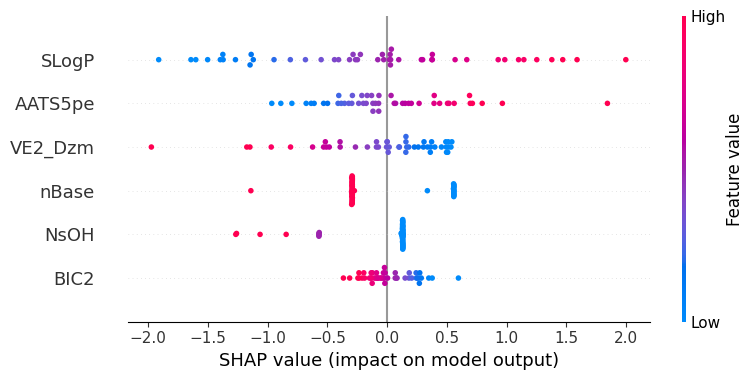

In [ ]:
import shap

X_train_summary = shap.kmeans(X_train_scaled, 20)

explainer = shap.KernelExplainer(mlp.predict, X_train_summary)
shap_values = explainer.shap_values(X_val_scaled)
shap.summary_plot(shap_values, X_val_scaled, selected_features_names)

Rubbish ahead

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 25.1 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):

  layer_configs = [(4, 2), (6, ), (6, 2)]

  idx = trial.suggest_categorical("layer_config", [0, 1, 2])
  alpha = trial.suggest_float('alpha', 0.001, 0.1, log=True)
  tol = trial.suggest_float('tol', 0.001, 0.1, log=True)

  mlp = MLPRegressor(hidden_layer_sizes=layer_configs[idx], activation='tanh', solver='lbfgs', alpha=alpha,
                    tol=tol, max_iter=100000, random_state=42)

  mlp.fit(X_train_scaled, y_train)

  val_pred = mlp.predict(X_val_scaled)
  valid_loss = mean_absolute_error(y_val, val_pred)

  return valid_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(study.best_trial)

[I 2026-02-27 16:10:58,825] A new study created in memory with name: no-name-63146644-033d-4fc0-b314-990340e84465
[I 2026-02-27 16:10:58,924] Trial 0 finished with value: 0.44490314373169737 and parameters: {'layer_config': 0, 'alpha': 0.002518779910070804, 'tol': 0.0038334055730432394}. Best is trial 0 with value: 0.44490314373169737.
[I 2026-02-27 16:10:59,036] Trial 1 finished with value: 0.42440374926397695 and parameters: {'layer_config': 1, 'alpha': 0.008104483771161776, 'tol': 0.0012934579791693906}. Best is trial 1 with value: 0.42440374926397695.
[I 2026-02-27 16:10:59,065] Trial 2 finished with value: 0.43604304057907584 and parameters: {'layer_config': 1, 'alpha': 0.017435112028921125, 'tol': 0.011274506719415609}. Best is trial 1 with value: 0.42440374926397695.
[I 2026-02-27 16:10:59,147] Trial 3 finished with value: 0.4382313218027624 and parameters: {'layer_config': 0, 'alpha': 0.02693525821927375, 'tol': 0.005128670287778027}. Best is trial 1 with value: 0.4244037492639

FrozenTrial(number=14, state=<TrialState.COMPLETE: 1>, values=[0.412555235614021], datetime_start=datetime.datetime(2026, 2, 27, 16, 11, 0, 302430), datetime_complete=datetime.datetime(2026, 2, 27, 16, 11, 0, 405103), params={'layer_config': 1, 'alpha': 0.013505814390994807, 'tol': 0.001978101518096132}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'layer_config': CategoricalDistribution(choices=(0, 1, 2)), 'alpha': FloatDistribution(high=0.1, log=True, low=0.001, step=None), 'tol': FloatDistribution(high=0.1, log=True, low=0.001, step=None)}, trial_id=14, value=None)


In [ ]:
X_train_summary

In [ ]:

!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 19.2 MB/s eta 0:00:00


In [ ]:
import random

import pickle

from sklearn.linear_model import LinearRegression




import optuna
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_preds = []
val_preds = []
test_preds = []

num_runs = 5

mlp = MLPRegressor(hidden_layer_sizes=(10), activation='relu', solver='lbfgs', alpha=0.0245, tol=0.0033,
                random_state=42, max_iter=600000)

mlp.fit(X_train_scaled, y_train)

train_pred = mlp.predict(X_train_scaled)
val_pred = mlp.predict(X_val_scaled)
test_pred = mlp.predict(X_test_scaled)

train_preds.append(train_pred)
val_preds.append(val_pred)
test_preds.append(test_pred)

for _ in range(num_runs - 1):

    mlp_ = MLPRegressor(hidden_layer_sizes=(10), activation='relu', solver='lbfgs', alpha=0.0245, tol=0.0033,
                random_state=_, max_iter=600000)

    mlp_.fit(X_train_scaled, y_train)

    train_pred = mlp_.predict(X_train_scaled)
    val_pred = mlp_.predict(X_val_scaled)
    test_pred = mlp_.predict(X_test_scaled)

    train_preds.append(train_pred)
    val_preds.append(val_pred)
    test_preds.append(test_pred)

train_pred = np.mean(train_preds, axis=0)
val_pred = np.mean(val_preds, axis=0)
test_pred = np.mean(test_preds, axis=0)

train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

val_r_squared = r2_score(y_val, val_pred)
val_mae = mean_absolute_error(y_val, val_pred)

test_r_squared = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"validation R²: {val_r_squared:.3f}")
print(f"validation MAE: {val_mae:.3f}")
print(f"test R²: {test_r_squared:.3f}")
print(f"test MAE: {test_mae:.3f}")

train R²: 0.942
train MAE: 0.372
validation R²: 0.916
validation MAE: 0.467
test R²: 0.898
test MAE: 0.443


In [ ]:
mlp

MLPRegressor(alpha=0.0245, hidden_layer_sizes=10, max_iter=600000,
             random_state=42, solver='lbfgs', tol=0.0033)

In [ ]:
ctrl

,substance,SMILES,RT
312,verapamil,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC...,6.887
313,terbufos,CCOP(=S)(OCC)SCSC(C)(C)C,8.680


In [ ]:
verapamil_smiles = 'CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC'
verapamil_mol = Chem.MolFromSmiles(verapamil_smiles)
verapamil_desc = np.array(calc(verapamil_mol)).reshape(1, -1)
verapamil_desc_scaled = normalizer.transform(verapamil_desc)

sample_pred = mlp.predict(verapamil_desc_scaled)[0]

print(f'Predicted RT = {sample_pred:.3f}')

Predicted RT = 7.853


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([7.85331096])

In [ ]:
target = df['RT']
descriptors = mordred_df[['nBase',
                          'AATS2p',
                          'ATSC3d',
                          'ATSC8pe',
                          'MATS2dv',
                          'MATS2d',
                          'MATS1Z',
                          'MATS1m',
                          'GATS4c',
                          'RNCG',
                          'NdsN',
                          'SaasN',
                          'SIC2',
                          'BIC2',
                          'ZMIC2',
                          'SLogP',
                          'GGI7',
                          'VAdjMat']]
#descriptors = mordred_df[['nBase','ATSC8pe','AATSC4i','MATS3dv','GATS4c','SdsN','SaasN','ZMIC2','FilterItLogS','piPC1','SLogP']] # excluded 'BCUTare-1l'

X_train, X_test, y_train, y_test = train_test_split(descriptors, target, test_size=0.20, random_state=seed)

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(18), activation='tanh', solver='lbfgs', alpha=0.5, tol=0.04,
                   random_state=42, max_iter=600000)

In [ ]:
#normalizer = MinMaxScaler()
#X_train = normalizer.fit_transform(X_train)
#X_test = normalizer.transform(X_test)

In [ ]:
print("Number of train samples: ", len(X_train))
print("Number of test samples: ", len(X_test))
print("Number of features: ", descriptors.shape[1])
print("Number of tasks: ", len(target.shape))

Number of train samples:  249
Number of test samples:  63
Number of features:  18
Number of tasks:  1


In [ ]:
mlp.fit(X_train, y_train)
train_pred = mlp.predict(X_train)
test_pred = mlp.predict(X_test)
train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)
test_r_squared = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"train R²: {test_r_squared:.3f}")
print(f"train MAE: {test_mae:.3f}")

train R²: 0.897
train MAE: 0.475
train R²: 0.919
train MAE: 0.452


In [ ]:
train_pred = pd.DataFrame(train_pred, columns=['RT'])
y_train = y_train.reset_index(drop=True)
train_pred = train_pred.reset_index(drop=True)
train_error = pd.concat([y_train, train_pred], axis=1)
train_error.columns = ['actual', 'pred']
test_pred = pd.DataFrame(test_pred, columns=['RT'])
y_test = y_test.reset_index(drop=True)
test_pred = test_pred.reset_index(drop=True)
test_error = pd.concat([y_test, test_pred], axis=1)
test_error.columns = ['actual', 'pred']

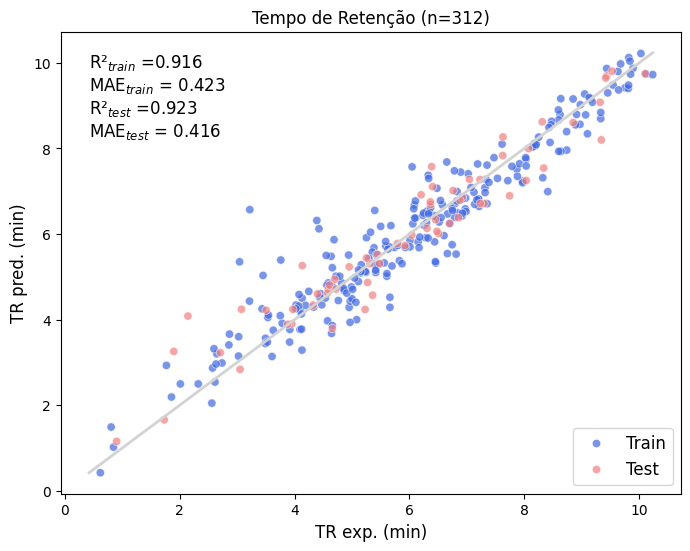

In [ ]:
# Add dataset labels to each DataFrame
train_error['dataset'] = 'Train'
test_error['dataset'] = 'Test'


# Merge all dataframes into one

merged = pd.concat([train_error, test_error], ignore_index=True)

# Count the number of points in each subset
dataset_sizes = merged['dataset'].value_counts().to_dict()

# Define the color palette
palette = {'Train': 'royalblue', 'Test': 'lightcoral'}

# Create the scatterplot
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(data=merged, x='actual', y='pred', hue='dataset', palette=palette, hue_order=palette.keys(), alpha=0.7)

# Add identity line (y = x)
min_val, max_val = merged[['actual', 'pred']].min().min(), merged[['actual', 'pred']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], color='lightgray', linewidth=2)

# Labels and title
plt.xlabel(r'TR exp. (min)', fontsize=12) #$t_R$ (min)
plt.ylabel(r'TR pred. (min)', fontsize=12)
plt.title(f'Tempo de Retenção (n={len(merged)})')
plt.tick_params(axis='both', which='major', labelsize=10)

legend_labels = [f"{key}" for key in palette.keys()]

# Create legend manually
handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles[:len(palette)], legend_labels, loc='lower right', fontsize=12)
#plt.legend(handles[:len(palette)], legend_labels, loc='lower right', fontsize=12)

# Display performance metrics (update with real values)
metrics_text = (r'R²$_{train}$ =' f"{train_r_squared:.3f} \n"
                r'MAE$_{train}$ =' f" {train_mae:.3f}\n"
                r'R²$_{test}$ =' f"{test_r_squared:.3f} \n"
                r'MAE$_{test}$ =' f" {test_mae:.3f}"#\n
                #r'R²$_{HOLBC}$ =' f"{r_squared[2]:.3f} \n"
                #r'MAE$_{HOLBC}$ =' f" {mae[2]:.3f}"
                )
plt.text(min_val, max_val, metrics_text, fontsize=12, verticalalignment='top')

# Show the plot
plt.show()

In [ ]:
smi = 'CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC'
#mol_descriptors = MordredCalculator(smi)
mol = Chem.MolFromSmiles(smi)
sample_desc = mordred_calc([mol])
sample_desc = sample_desc.select_dtypes(include=['float64', 'int64', 'float'])
sample_desc
pred_RT = m5p.predict(sample_desc)
pred_RT = pred_RT[0]
print(f'{pred_RT:.3f}')

TypeError: [<rdkit.Chem.rdchem.Mol object at 0x7b5de976eb20>] is not rdkit.Chem.Mol instance

In [ ]:
#Verapamil
actual_RT=6.887
pred_error = actual_RT - pred_RT
print(f'{pred_error:.3f}')
#

-0.444
